# Heads Up - Baseline & Model Development

| | |
|---|---|
| **Input** | `model_ready_train.csv`, `model_ready_val.csv` (46,026 / 7,890 orders, 28 engineered features) |
| **Output** | Trained models, validation metrics, and a final ranked comparison feeding Stage 8's hyperparameter tuning |

---

## Purpose of this notebook

This is the consolidated Stage 5/6 deliverable: a rule based baseline followed by **eleven ML models across five model families**, all compared on the same validation set.

> **The test set is never touched here.** Per our chronological three way split, it remains untouched until Stage 7's final evaluation.

**Models covered, in the order built:**

| # | Model | Family |
|---|---|---|
| 1 | Rule-based baseline | Non ML floor |
| 2 | Logistic Regression | Linear |
| 3 | Random Forest | Tree ensemble (bagging) |
| 4 | XGBoost | Tree ensemble (boosting) |
| 5 | SVM (Linear) | Linear |
| 6 | Neural Network (PyTorch MLP) | Deep learning |
| 7 | LightGBM | Tree ensemble (boosting) |
| 8 | CatBoost (+ native categorical variant) | Tree ensemble (boosting) |
| 9 | Gradient Boosting (sklearn) & AdaBoost | Tree ensemble (boosting) |
| 10 | Voting Classifier | Meta ensemble |
| 11 | Stacking Classifier | Meta ensemble |


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

Path('../reports/figures').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

model_ready_train = pd.read_csv(Path('../data/processed/model_ready_train.csv'))
model_ready_val = pd.read_csv(Path('../data/processed/model_ready_val.csv'))

bool_cols = model_ready_train.select_dtypes(include='bool').columns
model_ready_train[bool_cols] = model_ready_train[bool_cols].astype(int)
model_ready_val[bool_cols] = model_ready_val[bool_cols].astype(int)

X_train = model_ready_train.drop(columns=['Late_delivery_risk'])
y_train = model_ready_train['Late_delivery_risk']
X_val = model_ready_val.drop(columns=['Late_delivery_risk'])
y_val = model_ready_val['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")


X_train: (46026, 28), X_val: (7890, 28)


In [2]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve'); axes[1].legend(loc='lower right')
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — PR Curve'); axes[2].legend(loc='lower left')
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()
    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)


## 1. Rule based historical frequency baseline

A non ML baseline flagging an order "Late" based on historical delay rates.

> **Note on evaluation set:** the Initial Submission planned to evaluate the baseline on the test set. We use validation instead here, consistent with keeping test fully untouched until Stage 7 (see `DECISION_LOG.md`).


In [3]:
step3_train = pd.read_csv(Path('../data/processed/features_step3_train.csv'))
step3_val = pd.read_csv(Path('../data/processed/features_step3_val.csv'))

shipping_mode_delay_rate = step3_train.groupby('Shipping Mode')['Late_delivery_risk'].mean()
print("Shipping Mode delay rates (train):")
print(shipping_mode_delay_rate)


Shipping Mode delay rates (train):
Shipping Mode
First Class       0.955029
Same Day          0.443906
Second Class      0.768507
Standard Class    0.382626
Name: Late_delivery_risk, dtype: float64


### A bug we found and fixed here

> **The problem**
> The original rule flagged an order as "Late" if *either* of two conditions was true: Shipping Mode's historical rate was above 50%, **or** Order Region's historical rate was above 50%.
>
> **Why that broke**
> The dataset's overall late rate is already 54.8% - above 50% to begin with. Since region rates all cluster tightly around that overall average (EDA found only a 9 point spread across regions), almost every region's rate was already above 50% too, just because the whole dataset is. So the region condition ended up firing on nearly every single order, regardless of whether that order was actually high risk.
>
> **The result**
> The rule quietly turned into "always predict Late." That's why it showed 100% Recall (trivially easy to catch every late order if you flag everything) and 0% specificity (it never once predicted "on time").
>
> **The fix**
> Drop the region condition and use Shipping Mode alone. Shipping Mode gives genuine, wide discrimination on its own - First Class and Second Class both sit clearly above 50%, while Same Day and Standard Class both sit clearly below it - so this one condition is enough to produce a real, non degenerate rule.


--- Rule-based baseline (validation set) ---
  recall: 0.5349
  precision: 0.8391
  f1: 0.6533
  roc_auc: 0.7270
  pr_auc: 0.7429


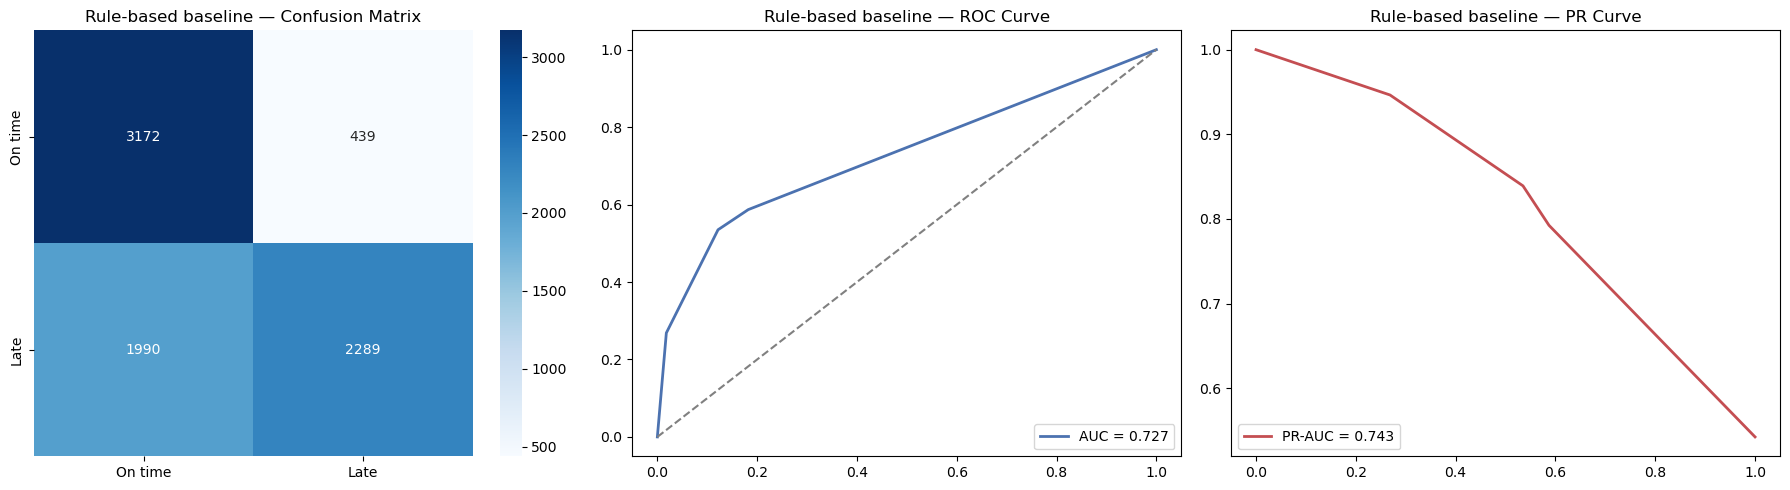

In [4]:
def apply_baseline_rule(df):
    df = df.copy()
    df['shipping_mode_delay_rate'] = df['Shipping Mode'].map(shipping_mode_delay_rate)
    df['baseline_pred'] = (df['shipping_mode_delay_rate'] > 0.5).astype(int)
    df['baseline_score'] = df['shipping_mode_delay_rate']
    return df

step3_val = apply_baseline_rule(step3_val)
baseline_metrics = evaluate_and_plot(
    step3_val['Late_delivery_risk'], step3_val['baseline_pred'], step3_val['baseline_score'],
    'Rule-based baseline', save_prefix='baseline'
)


**Baseline result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5349 |
| Precision | 0.8391 |
| F1 | 0.6533 |
| ROC-AUC | 0.7270 |

A genuinely meaningful floor - 84% Precision from a single feature is a real result, not a trivial one. Its weakness is Recall: it misses roughly half of actual late orders, specifically the ones shipped via modes with a delay rate just under 50% that still turn out late fairly often.

Every ML model below is measured against this corrected, non degenerate baseline.


In [5]:
save_metrics(baseline_metrics, '../data/processed/metrics_baseline.json')


## 2. Logistic Regression

Interpretable linear baseline.


--- Logistic Regression (validation set) ---
  recall: 0.5536
  precision: 0.8377
  f1: 0.6667
  roc_auc: 0.7394
  pr_auc: 0.8105


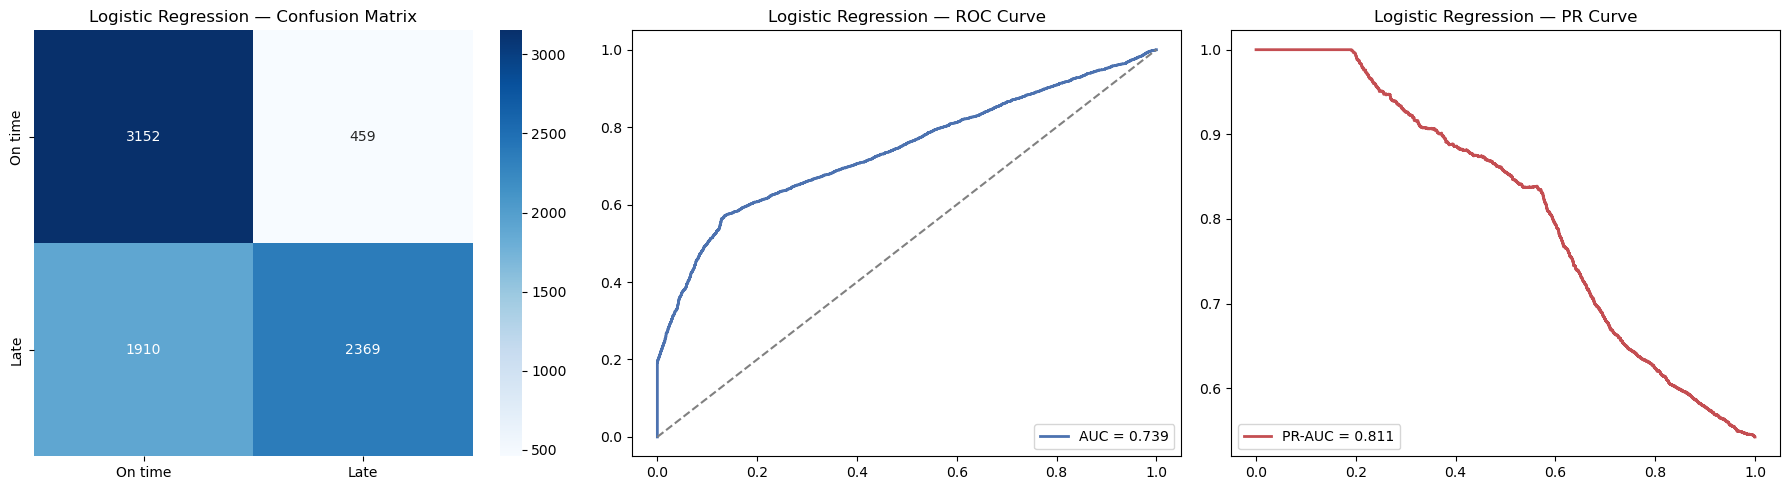

In [6]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_val)
y_score = log_reg.predict_proba(X_val)[:, 1]

logreg_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Logistic Regression', save_prefix='logreg')


**Logistic Regression result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5536 |
| Precision | 0.8377 |
| F1 | 0.6667 |
| ROC-AUC | 0.7394 |
| PR-AUC | 0.8105 |

A clean, consistent improvement over baseline on every metric with no tradeoff (Precision held flat). PR-AUC jumped nearly 7 points - meaningful headroom for Stage 8's threshold tuning.


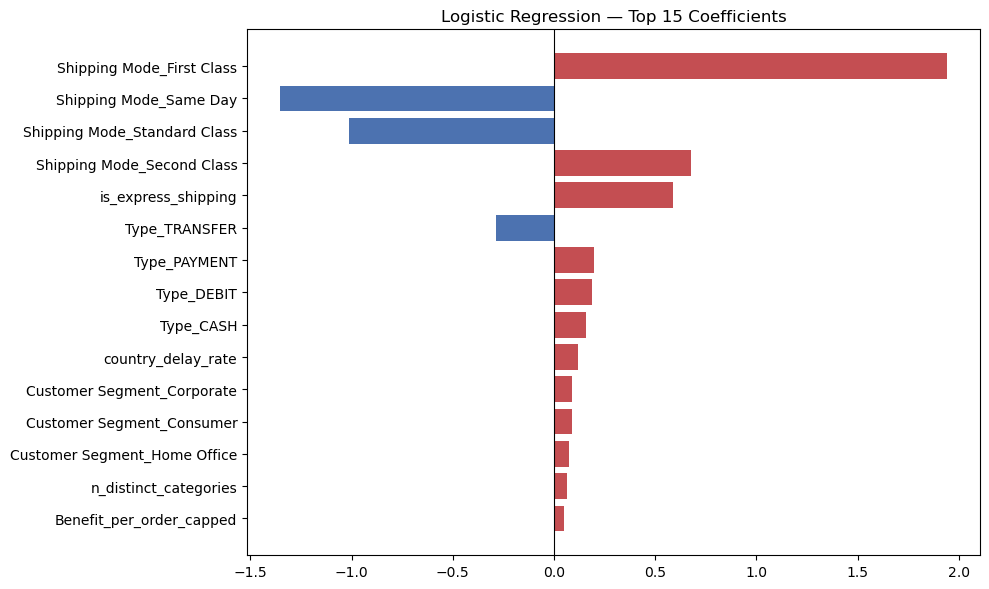

In [7]:
coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False).head(15)
plt.figure(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top 15 Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/logreg_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()


**Shipping Mode dominates the coefficients completely**, consistent with EDA's 57pp spread.

Interestingly, `country_delay_rate` (EDA's second strongest *univariate* signal) shows only a modest coefficient - a real, but expected, difference between univariate spread and multivariate marginal contribution once Shipping Mode already explains most of the variance.


In [8]:
joblib.dump(log_reg, '../models/logistic_regression.pkl')
save_metrics(logreg_metrics, '../data/processed/metrics_logreg.json')


## 3. Random Forest


--- Random Forest (validation set) ---
  recall: 0.6172
  precision: 0.7924
  f1: 0.6939
  roc_auc: 0.7580
  pr_auc: 0.8234


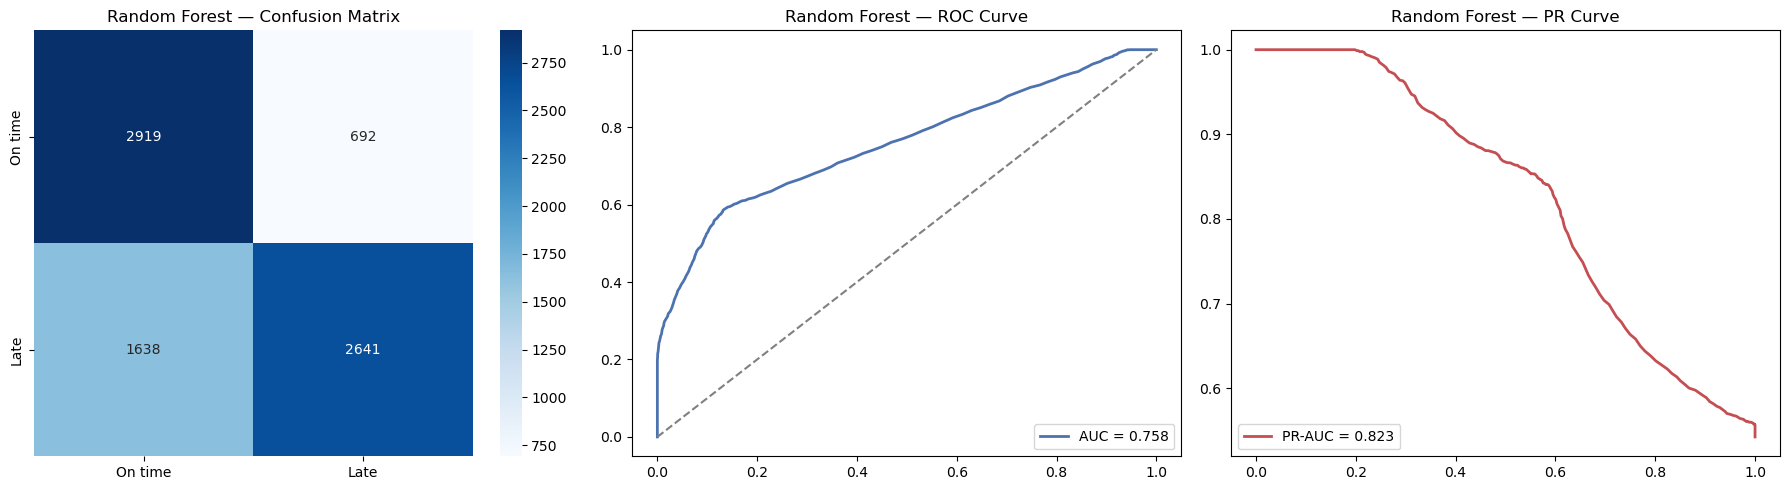

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
y_score = rf.predict_proba(X_val)[:, 1]

rf_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Random Forest', save_prefix='random_forest')


**Random Forest result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.6172 |
| Precision | 0.7924 |
| F1 | 0.6939 |
| ROC-AUC | 0.7580 |
| PR-AUC | 0.8234 |

A real Recall jump over Logistic Regression (**+6pp**), at a proportionate Precision cost - the right direction given Recall is our primary metric.


> **A genuine finding: **
> Random Forest's default (MDI based) feature importance ranked `order_hour` as the single most important feature, ahead of Shipping Mode - contradicting every other model and EDA itself. This is a known bias: MDI systematically favors high cardinality continuous features over low cardinality one hot columns. We checked with **permutation importance** instead, which is not subject to this bias.


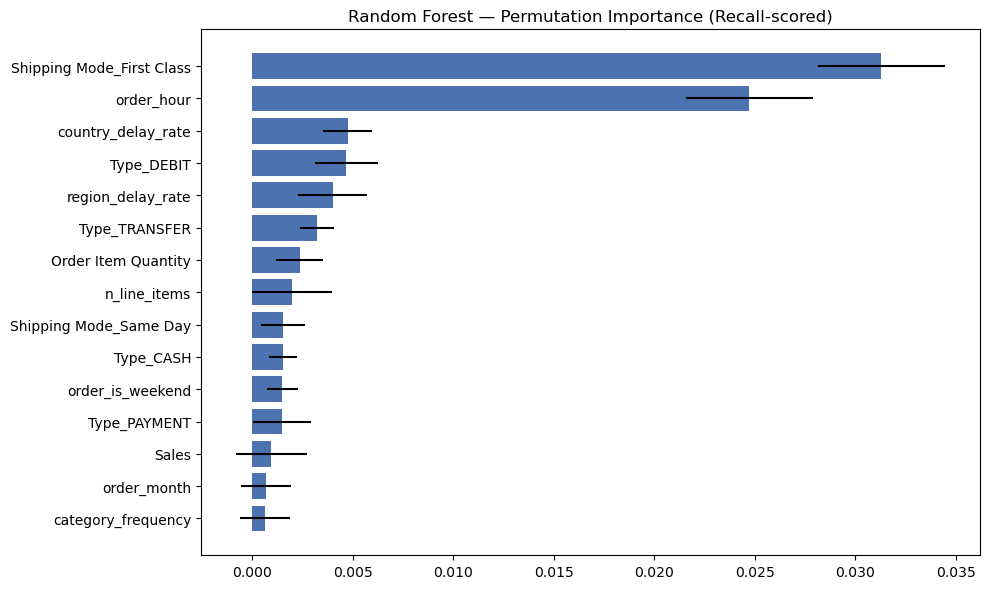

In [10]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='recall')
perm_df = pd.DataFrame({
    'feature': X_train.columns, 'importance_mean': perm_result.importances_mean, 'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color='#4C72B0')
plt.title('Random Forest — Permutation Importance (Recall-scored)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/rf_permutation_importance.png', dpi=120, bbox_inches='tight')
plt.show()


**Partially confirms the bias, with a genuine surprise attached.**

- `Shipping Mode_First Class` reclaims the top spot once corrected, as expected.
- But `order_hour` still ranks second, with a confidence interval that doesn't cross zero - this isn't just noise from the correction.

**Likely explanation:** permutation importance captures interaction effects a simple univariate EDA check can't. `order_hour` may not predict lateness alone, but combined with Shipping Mode or region, it may carry real signal.

> Flagged as an open question for Stage 8's SHAP analysis - not asserted outright here.


In [11]:
joblib.dump(rf, '../models/random_forest.pkl')
save_metrics(rf_metrics, '../data/processed/metrics_rf.json')


## 4. XGBoost


--- XGBoost (validation set) ---
  recall: 0.6062
  precision: 0.8160
  f1: 0.6956
  roc_auc: 0.7595
  pr_auc: 0.8250


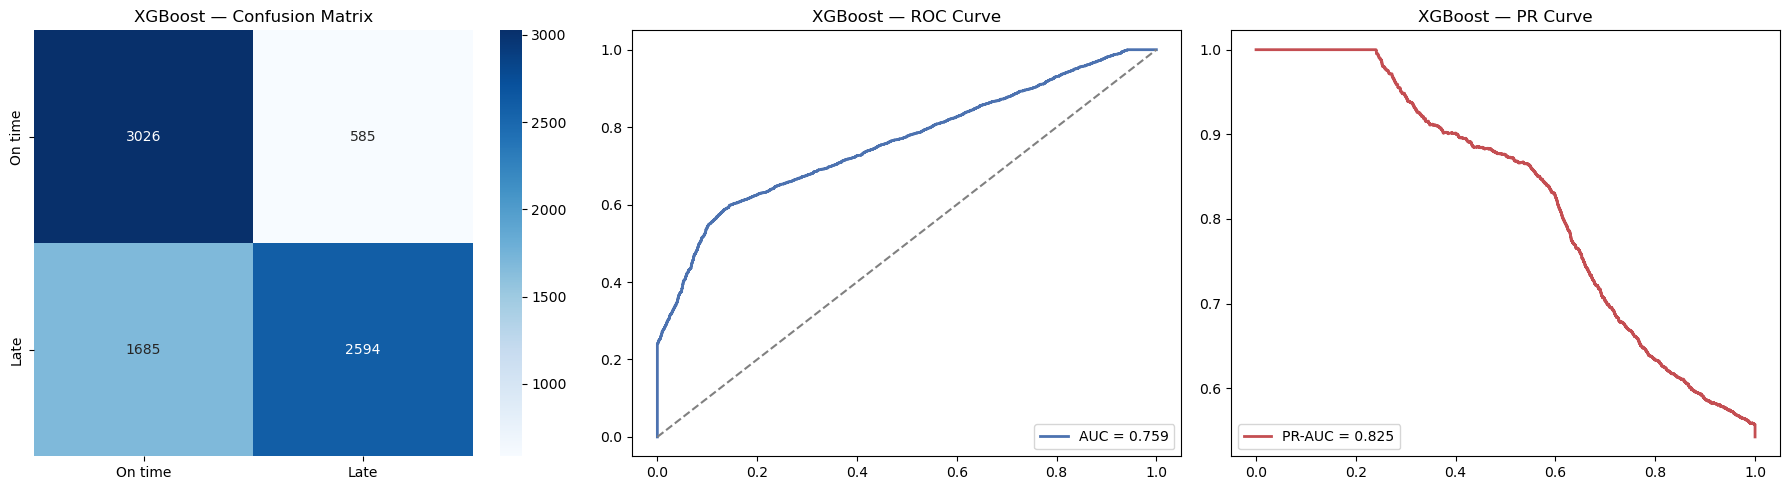

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_val)
y_score = xgb.predict_proba(X_val)[:, 1]

xgb_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'XGBoost', save_prefix='xgboost')


**XGBoost result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.6062 |
| Precision | 0.8160 |
| F1 | 0.6956 |
| ROC-AUC | 0.7595 |
| PR-AUC | 0.8250 |

F1 / ROC-AUC / PR-AUC are essentially tied with Random Forest (differences under 0.002), but the two trade Recall for Precision in opposite directions:

- **Random Forest** wins Recall (0.6172 vs 0.6062)
- **XGBoost** wins Precision (0.8160 vs 0.7924)

Since Recall is primary, **Random Forest is currently ahead on the metric that matters most**, despite XGBoost's stronger reputation. Neither should be eliminated before Stage 8's tuning.

> **Feature importance disagreement**
> XGBoost's gain based importance shows Shipping Mode accounting for over 90% of total importance - consistent with everything else, but directly contradicting Random Forest's `order_hour` finding (XGBoost's chart shows `order_hour` at ~1%). Two tree models disagreeing this much about one feature is exactly why SHAP is planned for Stage 8; neither built in importance measure should be trusted alone to settle it.


In [13]:
joblib.dump(xgb, '../models/xgboost.pkl')
save_metrics(xgb_metrics, '../data/processed/metrics_xgb.json')


## 5. SVM (Linear)

A deliberately different inductive bias (margin maximizing hinge loss, not log loss). `LinearSVC` is wrapped in `CalibratedClassifierCV` for probability scores, since a full kernel SVM's internal calibration is too slow at 46K rows.

> **A real convergence issue we caught here:**
> The first run used the default `max_iter=5000` and raised a "failed to converge" warning. That unconverged run produced a dramatically different result from Logistic Regression (Recall 0.71 vs. 0.55) that looked like a plausible story about hinge loss vs. log loss producing genuinely different tradeoffs.
>
> **After fixing convergence** (`max_iter=20000`, `dual=False` - the mathematically correct setting given far more rows than features), the result changed completely.


--- SVM (Linear) (validation set) ---
  recall: 0.5618
  precision: 0.8394
  f1: 0.6731
  roc_auc: 0.7392
  pr_auc: 0.8102


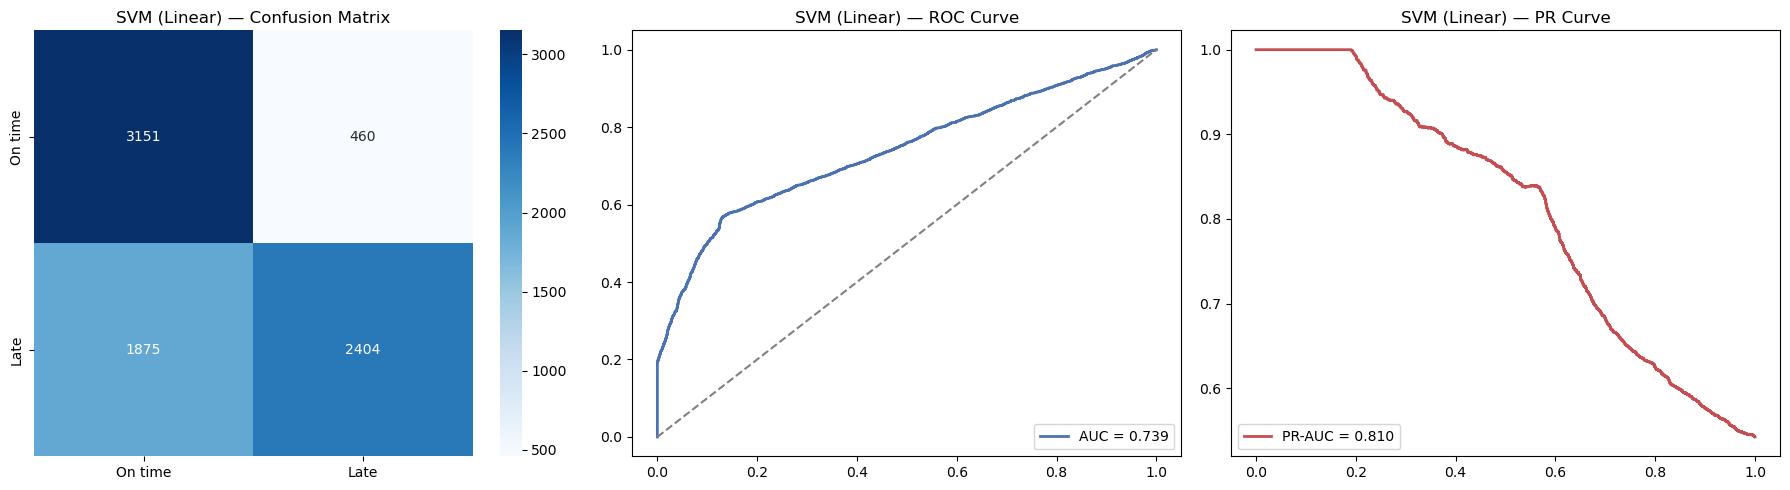

In [14]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(max_iter=20000, dual=False, random_state=42)
svm = CalibratedClassifierCV(base_svm, cv=3)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_val)
y_score = svm.predict_proba(X_val)[:, 1]

svm_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'SVM (Linear)', save_prefix='svm')


**SVM (Linear) result, once properly converged (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5618 |
| Precision | 0.8394 |
| F1 | 0.6731 |
| ROC-AUC | 0.7392 |
| PR-AUC | 0.8102 |

Nearly identical to Logistic Regression. The earlier "dramatic difference" was entirely an optimizer artifact, not a real algorithmic effect - a good, concrete example of not trusting a surprising result before checking for basic issues like convergence, worth keeping in the decision log as validation discipline evidence.

**Practical takeaway:** SVM adds nothing distinct from Logistic Regression on this data; no reason to carry both forward as separate candidates.


In [15]:
joblib.dump(svm, '../models/svm.pkl')
save_metrics(svm_metrics, '../data/processed/metrics_svm.json')


## 6. Neural Network (PyTorch)

A simple feedforward MLP (64→32→1, dropout, Adam), testing whether deep learning adds value over tree based/linear models here. **Stated honestly going in: not expected to beat XGBoost at this data scale** (46K rows, 28 tabular features), gradient boosting is generally the stronger default choice on structured data. Reporting the result either way is a legitimate finding.


In [16]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_np = X_train.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)
y_val_np = y_val.values.astype(np.float32)

class DelayRiskMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train_np)), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_np), torch.tensor(y_val_np)), batch_size=512, shuffle=False)

nn_model = DelayRiskMLP(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)


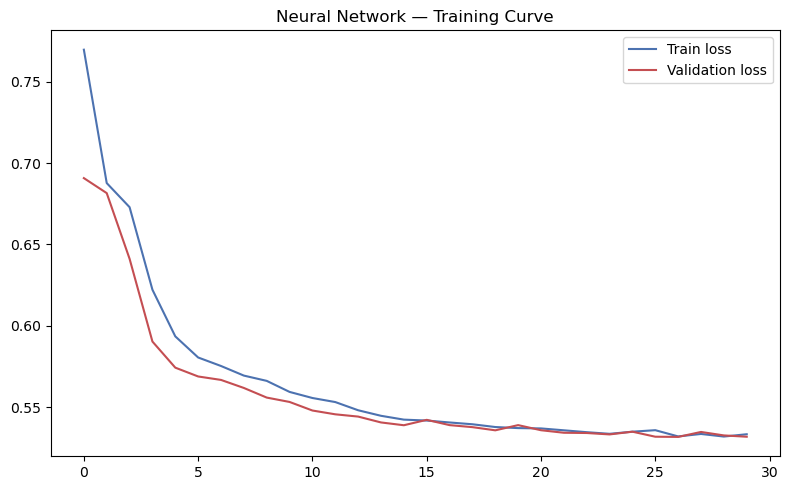

In [17]:
N_EPOCHS = 30
train_losses, val_losses = [], []
for epoch in range(N_EPOCHS):
    nn_model.train()
    epoch_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(xb).squeeze(), yb)
        loss.backward(); optimizer.step()
        epoch_train_loss += loss.item() * xb.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    nn_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(nn_model(xb).squeeze(), yb)
            epoch_val_loss += loss.item() * xb.size(0)
    epoch_val_loss /= len(val_loader.dataset)

    train_losses.append(epoch_train_loss); val_losses.append(epoch_val_loss)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train loss', color='#4C72B0')
plt.plot(val_losses, label='Validation loss', color='#C44E52')
plt.title('Neural Network — Training Curve'); plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nn_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()


**A clean, healthy training curve, no overfitting** - train and validation loss decrease together smoothly across all 30 epochs and converge closely.


--- Neural Network (PyTorch) (validation set) ---
  recall: 0.5857
  precision: 0.8458
  f1: 0.6921
  roc_auc: 0.7653
  pr_auc: 0.8301


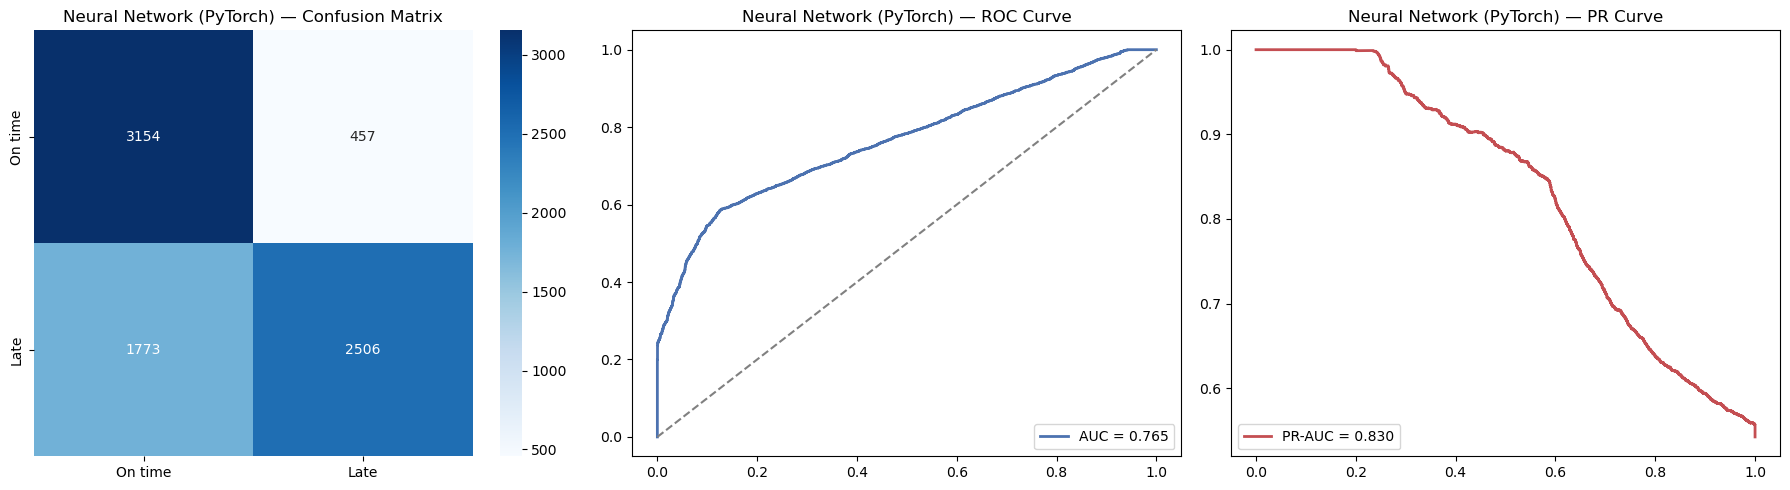

In [18]:
nn_model.eval()
with torch.no_grad():
    val_logits = nn_model(torch.tensor(X_val_np).to(device)).squeeze().cpu().numpy()
    y_score = 1 / (1 + np.exp(-val_logits))
    y_pred = (y_score >= 0.5).astype(int)

nn_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Neural Network (PyTorch)', save_prefix='neural_network')


**Neural Network (PyTorch) result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5857 |
| Precision | 0.8458 |
| F1 | 0.6921 |
| ROC-AUC | 0.7653 |
| PR-AUC | 0.8301 |

Contrary to the stated expectation, **this is the best ROC-AUC, PR-AUC, and Precision of every model in the formal comparison.** It does not lead on Recall (Random Forest still holds that), but this pushes back honestly against "gradient boosting always wins on tabular data" - it didn't automatically win here, at least not on every metric, and that's a genuinely interesting, tested finding rather than an assumed one.


In [19]:
torch.save(nn_model.state_dict(), '../models/neural_network.pt')
save_metrics(nn_metrics, '../data/processed/metrics_nn.json')


## 7. LightGBM

A gradient boosted model that grows trees leaf-wise rather than XGBoost's level wise growth, a genuine algorithmic difference.


--- LightGBM (validation set) ---
  recall: 0.6011
  precision: 0.8236
  f1: 0.6949
  roc_auc: 0.7643
  pr_auc: 0.8290


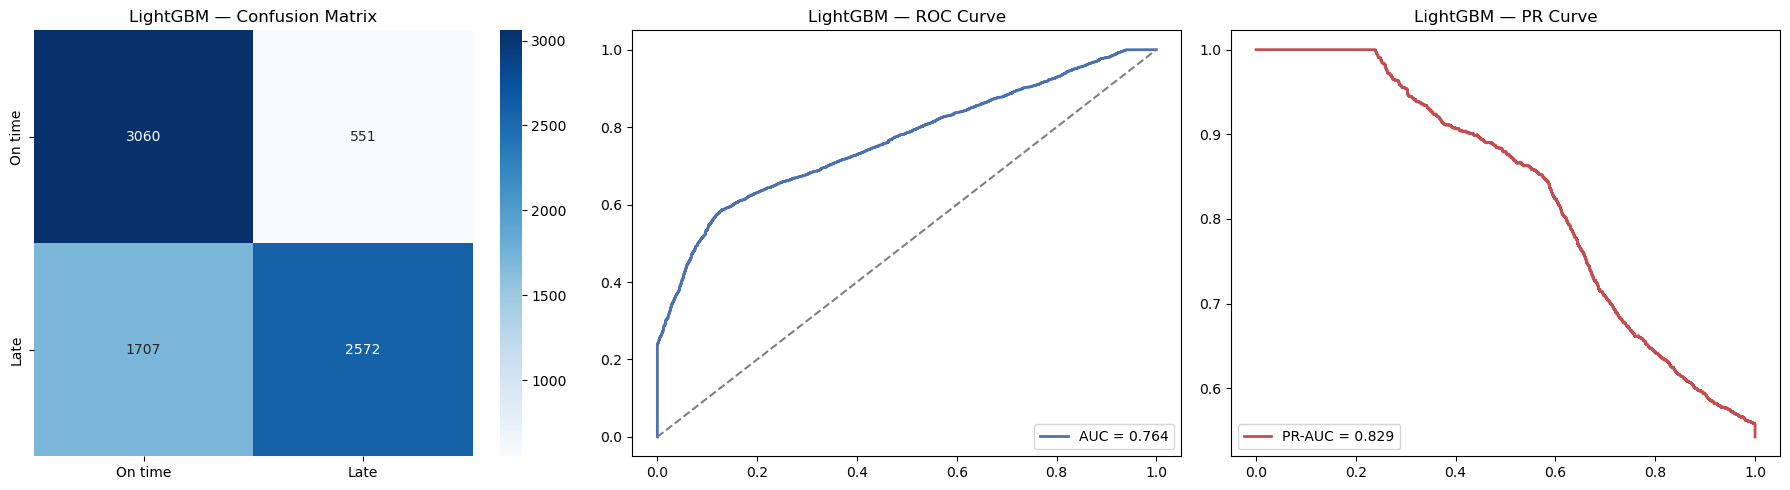

In [20]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, max_depth=-1, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_val)
y_score = lgbm.predict_proba(X_val)[:, 1]

lgbm_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'LightGBM', save_prefix='lightgbm')


**LightGBM result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.6011 |
| Precision | 0.8236 |
| F1 | 0.6949 |
| ROC-AUC | 0.7643 |
| PR-AUC | 0.8290 |

**Essentially tied with XGBoost** (every difference under a percentage point). Two independent boosting implementations converging to nearly the same performance is a good consistency signal - the underlying patterns in the data are real, not an artifact of one library.

> **Same importance bias as Random Forest**
> LightGBM's default importance chart shows the same cardinality bias problem already caught in Random Forest: `Shipping Mode` doesn't even appear in its top 15, dominated instead by continuous features like `Benefit per order` and `Sales`. This is LightGBM's default `importance_type='split'` - the same class of bias as Random Forest's MDI. This is now the *second* tree model whose default importance chart has looked misleading, reinforcing why SHAP is the right tool for Stage 8's real interpretability story, not any single model's built in chart.


In [21]:
joblib.dump(lgbm, '../models/lightgbm.pkl')
save_metrics(lgbm_metrics, '../data/processed/metrics_lightgbm.json')


## 8. CatBoost

Distinguished by native categorical handling, no one hot or target encoding needed.


--- CatBoost (validation set) ---
  recall: 0.5936
  precision: 0.8358
  f1: 0.6942
  roc_auc: 0.7642
  pr_auc: 0.8284


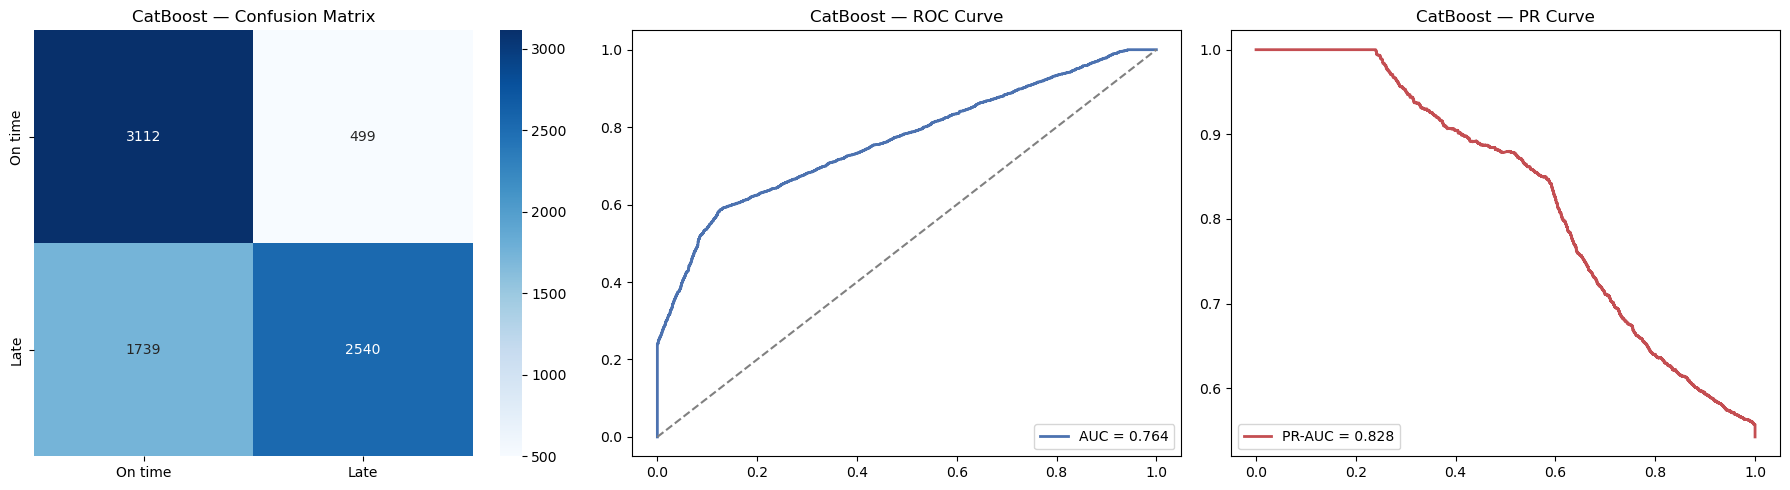

In [22]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False)
catboost_model.fit(X_train, y_train)
y_pred = catboost_model.predict(X_val)
y_score = catboost_model.predict_proba(X_val)[:, 1]

catboost_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'CatBoost', save_prefix='catboost')


**CatBoost result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5936 |
| Precision | 0.8358 |
| F1 | 0.6942 |
| ROC-AUC | 0.7642 |
| PR-AUC | 0.8284 |

A third boosting library, a third near identical result to XGBoost and LightGBM - confirming the modern boosting cluster is genuinely interchangeable at default settings on this dataset.


In [23]:
joblib.dump(catboost_model, '../models/catboost.pkl')
save_metrics(catboost_metrics, '../data/processed/metrics_catboost.json')


**Optional: native categorical handling** - illustrative only, uses raw categoricals directly rather than the encoded feature matrix. Not included in the final model comparison table below, since it runs on a different feature set.


--- CatBoost (native categoricals) (validation set) ---
  recall: 0.5892
  precision: 0.8446
  f1: 0.6941
  roc_auc: 0.7672
  pr_auc: 0.8305


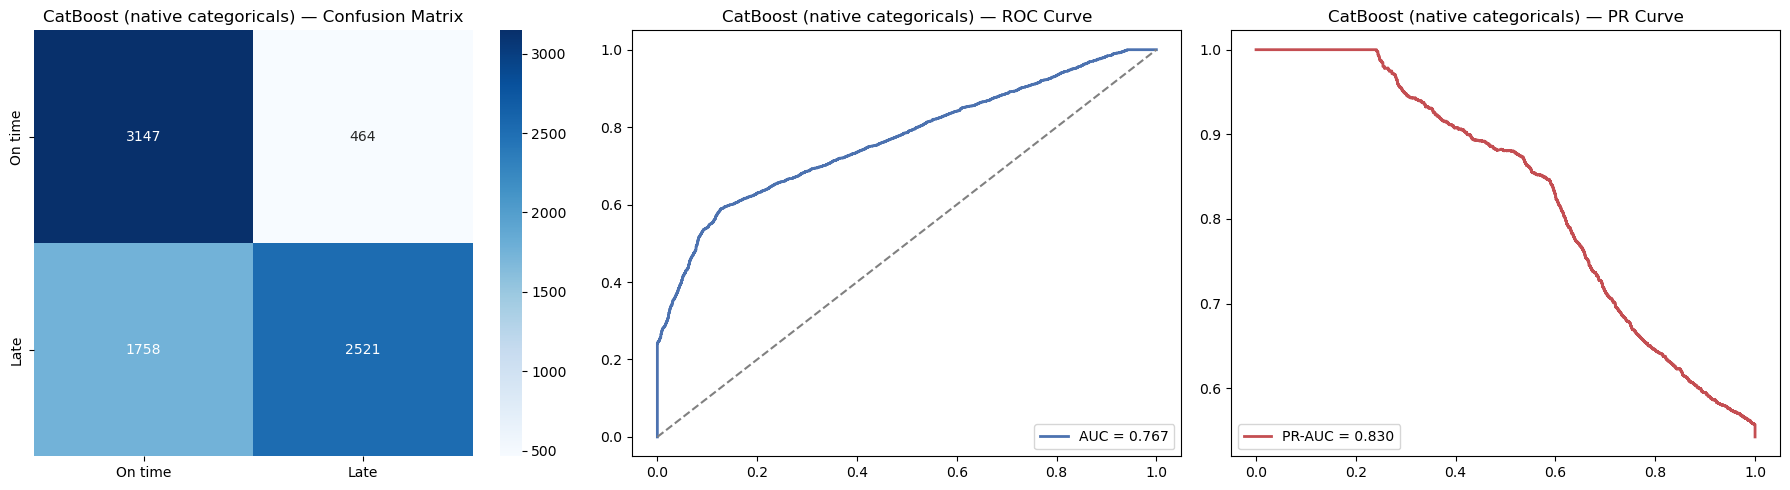

In [24]:
step3_train_raw = pd.read_csv(Path('../data/processed/features_step3_train.csv'))
step3_val_raw = pd.read_csv(Path('../data/processed/features_step3_val.csv'))

cat_features = ['Shipping Mode', 'Customer Segment', 'Type', 'Category Name']
drop_cols = ['Order Id', 'Order Country', 'Order Region', 'Order City', 'Order State',
             'Category Id', 'order date (DateOrders)', 'Delivery Status']
drop_cols = [c for c in drop_cols if c in step3_train_raw.columns]

X_train_raw = step3_train_raw.drop(columns=drop_cols + ['Late_delivery_risk'])
y_train_raw = step3_train_raw['Late_delivery_risk']
X_val_raw = step3_val_raw.drop(columns=drop_cols + ['Late_delivery_risk'])
y_val_raw = step3_val_raw['Late_delivery_risk']

catboost_native = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False)
catboost_native.fit(X_train_raw, y_train_raw, cat_features=cat_features)
y_pred_native = catboost_native.predict(X_val_raw)
y_score_native = catboost_native.predict_proba(X_val_raw)[:, 1]

native_metrics = evaluate_and_plot(y_val_raw, y_pred_native, y_score_native, 'CatBoost (native categoricals)', save_prefix='catboost_native')


**CatBoost (native categoricals) result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5892 |
| Precision | 0.8446 |
| F1 | 0.6941 |
| ROC-AUC | 0.7672 |
| PR-AUC | 0.8305 |

Comparable or marginally better than the standard encoded run, despite skipping one hot/frequency encoding entirely.

**A genuinely useful practical finding:** native categorical handling isn't just a convenience feature - it delivers equivalent performance with meaningfully less preprocessing, worth weighing for a production deployment where new categories might appear over time.


## 9. Gradient Boosting (sklearn) & AdaBoost

Two classical boosting predecessors, included to test whether "boosting evolved and got better" actually holds on this data.


--- Gradient Boosting (sklearn) (validation set) ---
  recall: 0.5917
  precision: 0.8409
  f1: 0.6947
  roc_auc: 0.7639
  pr_auc: 0.8290


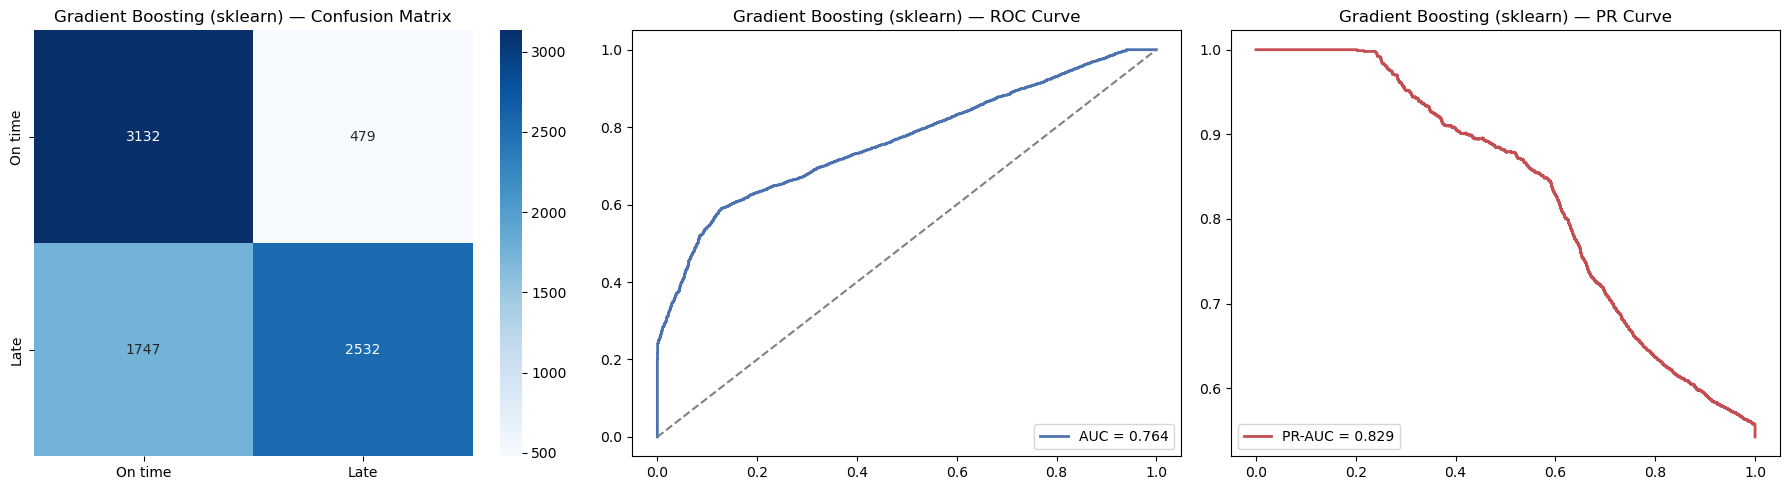

In [25]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_val)
y_score_gb = gb.predict_proba(X_val)[:, 1]
gb_metrics = evaluate_and_plot(y_val, y_pred_gb, y_score_gb, 'Gradient Boosting (sklearn)', save_prefix='gradient_boosting')


**Gradient Boosting (sklearn) result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5917 |
| Precision | 0.8409 *(highest Precision of any boosting model)* |
| F1 | 0.6947 |
| ROC-AUC | 0.7639 |
| PR-AUC | 0.8290 |

This directly contradicts the expectation that classical Gradient Boosting would be noticeably weaker - it's statistically indistinguishable from XGBoost/LightGBM/CatBoost on accuracy. The real advantage of the modern libraries is almost certainly training speed (histogram based optimization), not accuracy


C:\Users\Ewis\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


--- AdaBoost (validation set) ---
  recall: 0.5695
  precision: 0.8363
  f1: 0.6776
  roc_auc: 0.7393
  pr_auc: 0.8053


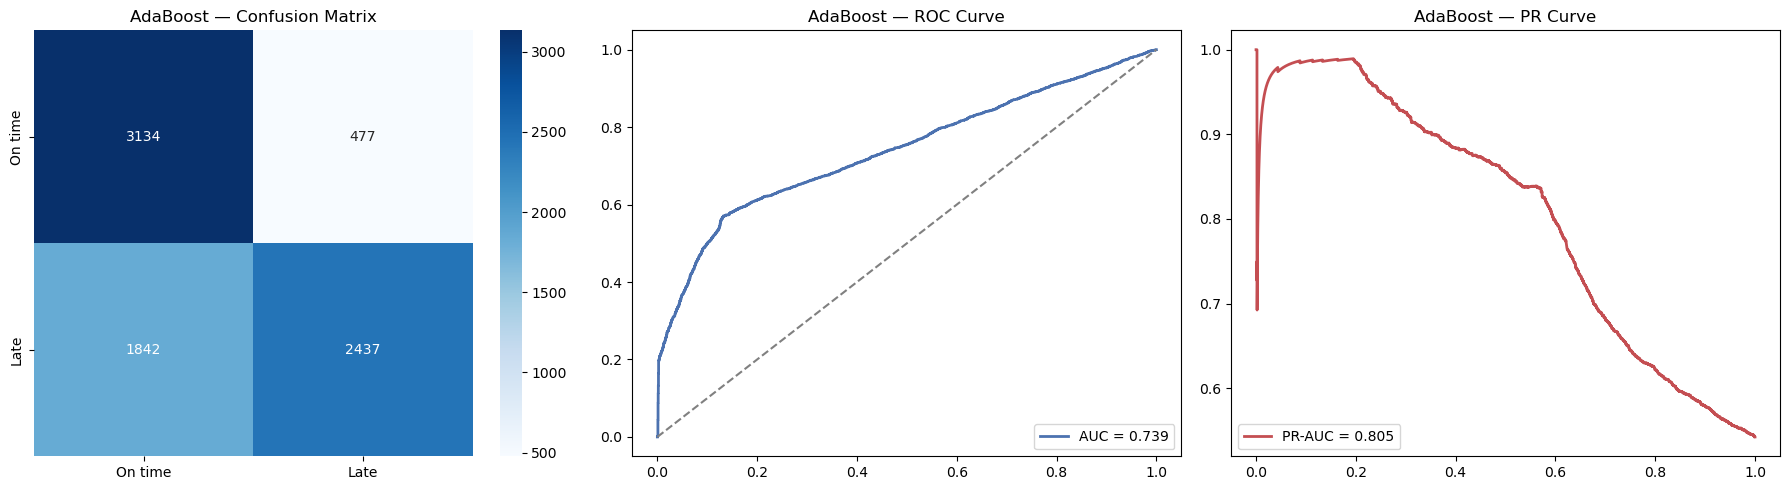

In [26]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_val)
y_score_ada = ada.predict_proba(X_val)[:, 1]
ada_metrics = evaluate_and_plot(y_val, y_pred_ada, y_score_ada, 'AdaBoost', save_prefix='adaboost')


**AdaBoost result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5695 |
| Precision | 0.8363 |
| F1 | 0.6776 |
| ROC-AUC | 0.7393 |
| PR-AUC | 0.8053 |

AdaBoost does underperform - its ROC-AUC lands at the same level as the *linear* models, not the tree ensembles.

This gives a precise version of the boosting story: **AdaBoost → Gradient Boosting was a genuine accuracy improvement; Gradient Boosting → the modern three was primarily a speed/engineering improvement, not an accuracy one, on this dataset.**


In [27]:
joblib.dump(gb, '../models/gradient_boosting.pkl')
joblib.dump(ada, '../models/adaboost.pkl')
save_metrics(gb_metrics, '../data/processed/metrics_gb.json')
save_metrics(ada_metrics, '../data/processed/metrics_adaboost.json')


## 10. Voting Classifier

Combines the top 4 sklearn compatible models (ranked by validation Recall) via soft voting, averaging predicted probabilities.


--- Voting Classifier (validation set) ---
  recall: 0.5966
  precision: 0.8321
  f1: 0.6950
  roc_auc: 0.7616
  pr_auc: 0.8276


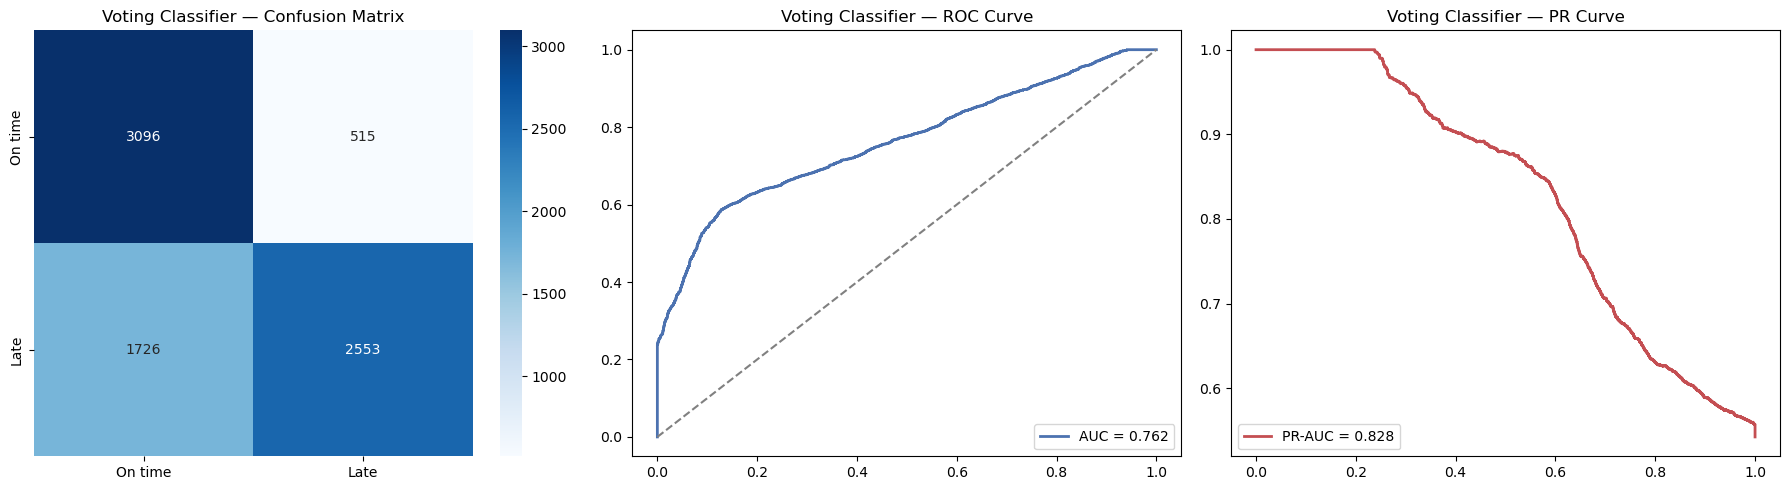

In [28]:
from sklearn.ensemble import VotingClassifier

eligible = {
    'Logistic Regression': logreg_metrics, 'SVM (Linear)': svm_metrics, 'AdaBoost': ada_metrics,
    'Gradient Boosting': gb_metrics, 'Random Forest': rf_metrics, 'XGBoost': xgb_metrics,
    'LightGBM': lgbm_metrics, 'CatBoost': catboost_metrics,
}
ranked = pd.DataFrame(eligible.values()).set_index('model').sort_values('recall', ascending=False)
top_4_names = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']  # confirmed top 4 by Recall

model_builders = {
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lambda: LGBMClassifier(n_estimators=200, max_depth=-1, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': lambda: CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False),
}
estimators = [(name.lower(), model_builders[name]()) for name in top_4_names]

voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_val)
y_score = voting_clf.predict_proba(X_val)[:, 1]

voting_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Voting Classifier', save_prefix='voting')


**Voting Classifier result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5966 *(down ~2pp from Random Forest alone)* |
| Precision | 0.8321 |
| F1 | 0.6950 |
| ROC-AUC | 0.7616 |
| PR-AUC | 0.8276 |

The top 4 selected were all tree/boosting models - no linear model made the cut - so the ensemble lacks genuine diversity. Averaging Random Forest's relatively aggressive, high Recall behavior with three Precision favoring boosting models pulls the combined prediction toward the more conservative consensus, diluting the exact behavior that made Random Forest attractive.


In [29]:
joblib.dump(voting_clf, '../models/voting_classifier.pkl')
save_metrics(voting_metrics, '../data/processed/metrics_voting.json')


## 11. Stacking Classifier

Same top 4 base models, but a Logistic Regression meta learner learns how to weight them instead of simple averaging.

> **Note:** the outer ensemble's `n_jobs` must stay at its default (not `-1`), since several base models already parallelize internally; nesting two levels of parallel workers caused a `MemoryError` in an earlier run.


--- Stacking Classifier (validation set) ---
  recall: 0.5973
  precision: 0.8299
  f1: 0.6947
  roc_auc: 0.7641
  pr_auc: 0.8288


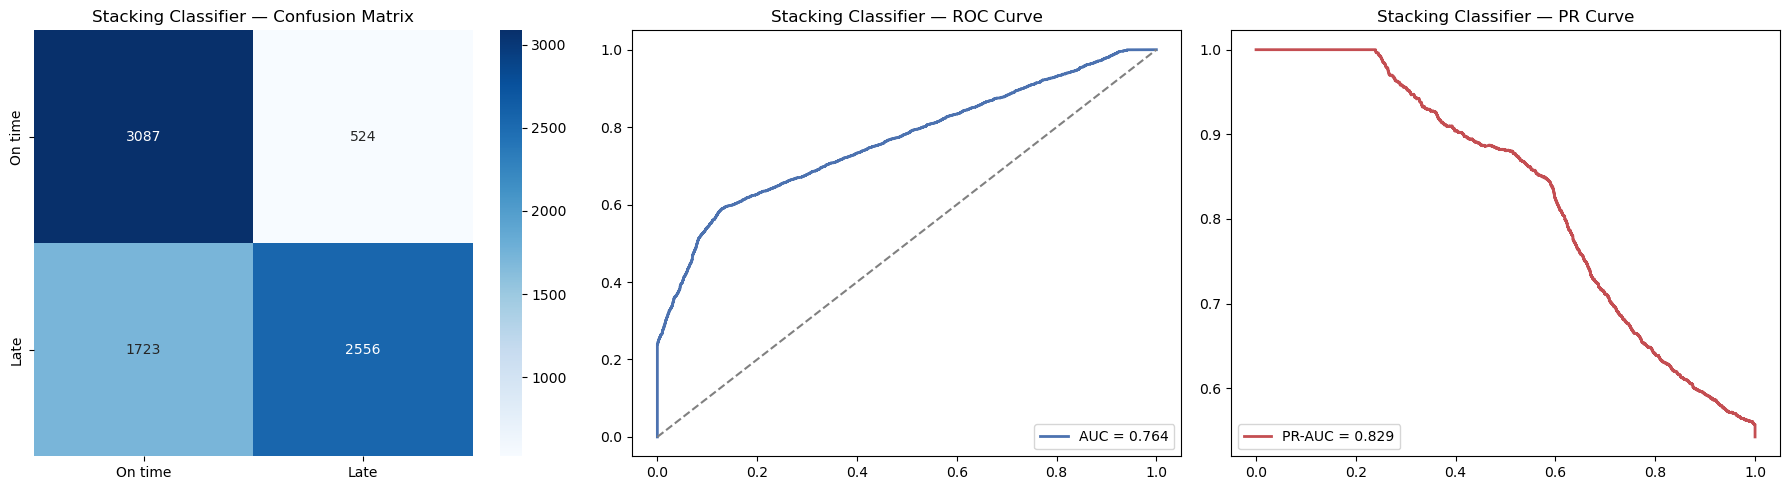

In [30]:
from sklearn.ensemble import StackingClassifier

estimators = [(name.lower(), model_builders[name]()) for name in top_4_names]
stacking_clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression(max_iter=1000, random_state=42), cv=3,
)
stacking_clf.fit(X_train, y_train)
y_pred = stacking_clf.predict(X_val)
y_score = stacking_clf.predict_proba(X_val)[:, 1]

stacking_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Stacking Classifier', save_prefix='stacking')


**Stacking Classifier result (validation set):**

| Metric | Value |
|---|---|
| Recall | 0.5973 |
| Precision | 0.8299 |
| F1 | 0.6947 |
| ROC-AUC | 0.7641 |
| PR-AUC | 0.8288 |

Essentially identical to Voting. Giving the ensemble a smarter, learned combination method didn't fix the core problem, because the problem was never the combination method - it was the lack of diversity among the 4 base models.


In [31]:
meta_coef_df = pd.DataFrame({
    'base_model': top_4_names, 'meta_weight': stacking_clf.final_estimator_.coef_[0]
}).sort_values('meta_weight', ascending=False)
meta_coef_df


,base_model,meta_weight
3,CatBoost,3.803476
2,LightGBM,0.950891
0,Random Forest,0.633188
1,XGBoost,-0.128762


**The meta learner's weights explain exactly why:**

- CatBoost gets by far the highest weight (~3.8), despite having the *lowest* individual Recall of the four
- XGBoost gets a slightly negative weight, despite being the second best individual performer

The meta learner optimizes its own log loss objective, not our Recall priority - favoring whichever base models produce the best-*calibrated* probabilities rather than the one best at the metric we actually care about.

> **Both ensembles are therefore not recommended for Stage 8** - they currently underperform Random Forest alone on Recall, and the added deployment complexity isn't earning its keep.


In [32]:
joblib.dump(stacking_clf, '../models/stacking_classifier.pkl')
save_metrics(stacking_metrics, '../data/processed/metrics_stacking.json')


## 12. Final comparison and recommendation


In [33]:
all_metrics_dicts = [
    baseline_metrics, logreg_metrics, rf_metrics, xgb_metrics, svm_metrics, nn_metrics,
    lgbm_metrics, catboost_metrics, gb_metrics, ada_metrics, voting_metrics, stacking_metrics,
]
comparison_df = pd.DataFrame(all_metrics_dicts).set_index('model')
comparison_df = comparison_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].round(4)
comparison_df = comparison_df.sort_values('recall', ascending=False)
comparison_df


,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.6172,0.7924,0.6939,0.7580,0.8234
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
Stacking Classifier,0.5973,0.8299,0.6947,0.7641,0.8288
Voting Classifier,0.5966,0.8321,0.6950,0.7616,0.8276
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
Neural Network (PyTorch),0.5857,0.8458,0.6921,0.7653,0.8301
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053


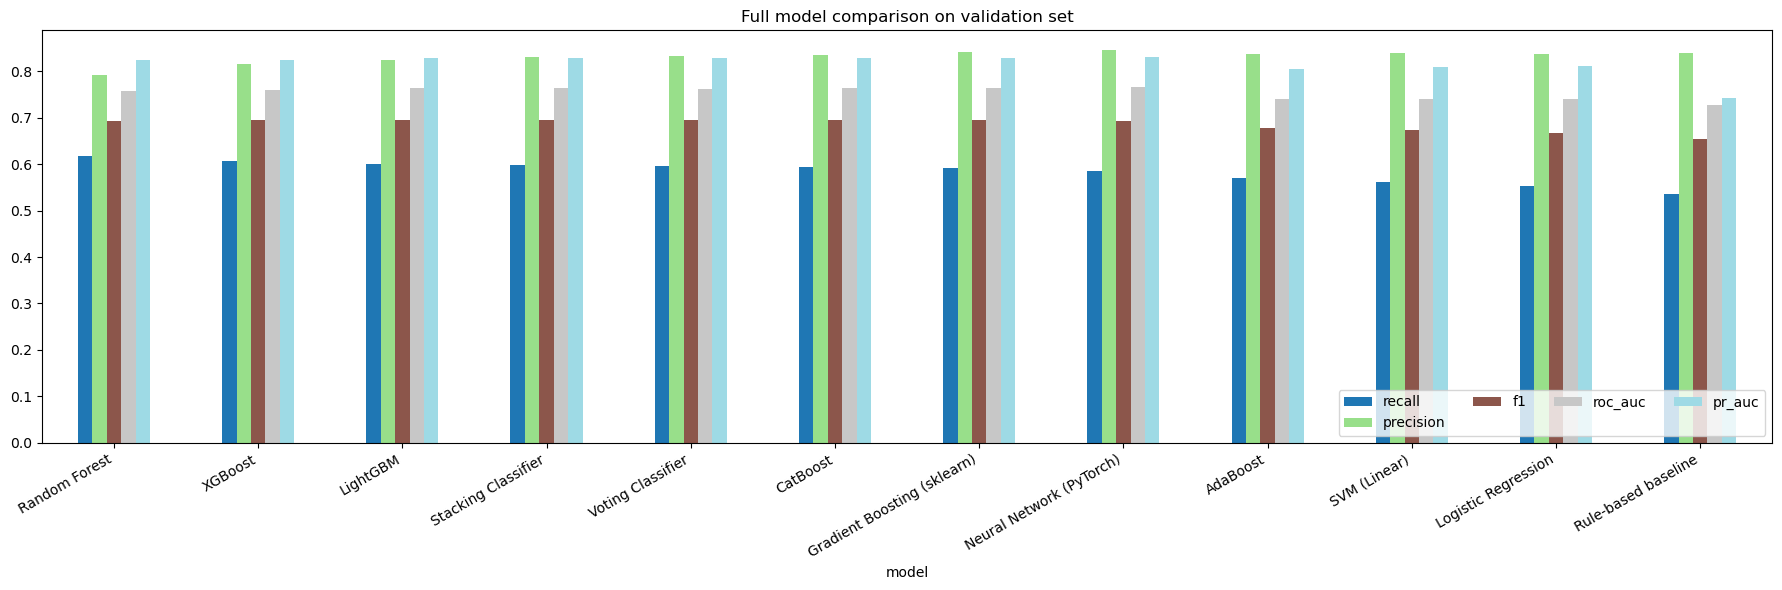

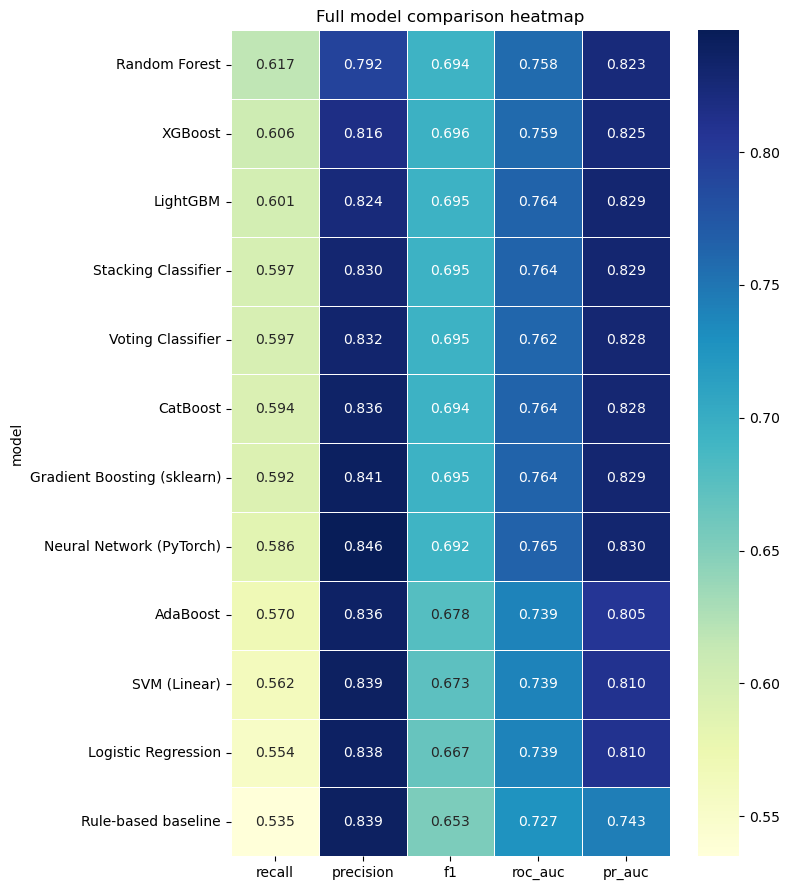

In [34]:
comparison_df.plot(kind='bar', figsize=(18, 6), colormap='tab20')
plt.title('Full model comparison on validation set')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', ncol=4)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_bars_final.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 9))
sns.heatmap(comparison_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Full model comparison heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_heatmap_final.png', dpi=120, bbox_inches='tight')
plt.show()


### Summary of findings

1. **Random Forest leads on Recall** (0.6172), our primary metric, ahead of every other model including both purpose built ensembles. The baseline to best gap is a real 8.2 points.
2. **The boosting family does not show a clean "newer is better" progression.** AdaBoost underperforms clearly; sklearn's classical Gradient Boosting ties with XGBoost, LightGBM, and CatBoost. The real story: AdaBoost → Gradient Boosting was a genuine accuracy improvement, Gradient Boosting → the modern three was primarily a speed/engineering improvement.
3. **Both ensembles (Voting, Stacking) underperformed the best single model on Recall**, traced directly to a lack of base model diversity and a meta learner optimizing the wrong objective - a well evidenced negative result, not just a null one.
4. **The Neural Network leads every ranking quality metric** (ROC-AUC, PR-AUC, Precision) in the formal comparison, directly contradicting the stated expectation that it wouldn't beat gradient boosting here.
5. **SVM and Logistic Regression are functionally identical** once SVM's convergence issue was fixed, confirming they're not distinct candidates.

### Final candidates for Stage 8 (Optuna hyperparameter tuning)

- **Random Forest** - current Recall leader
- **Neural Network** - best ranking quality, meaning the most headroom to gain Recall once the classification threshold is tuned away from the default 0.5
- **XGBoost** - a reasonable third, given how close it sits to Random Forest

Neither ensemble (Voting, Stacking) is recommended for further tuning.

### Next stage

The test set remains untouched until Stage 7's final evaluation of the fully tuned model.
